In [1]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.clients.fdsn.header import FDSNNoDataException
from IPython.display import clear_output
import matplotlib.pyplot as plt
import time

from obspy.signal.trigger import classic_sta_lta, trigger_onset

In [2]:
NETWORK = "IV"
STATION = "GIZZ"
LOCATION = "*"
CHANNEL = "HHZ"

WINDOW = 60
INTERVAL = 5

In [3]:
client = Client("INGV")

Stazione: IV.GIZZ..HHZ
Start: 2026-03-17T14:45:21.220000Z
End: 2026-03-17T14:46:18.990000Z
Campioni: 5778


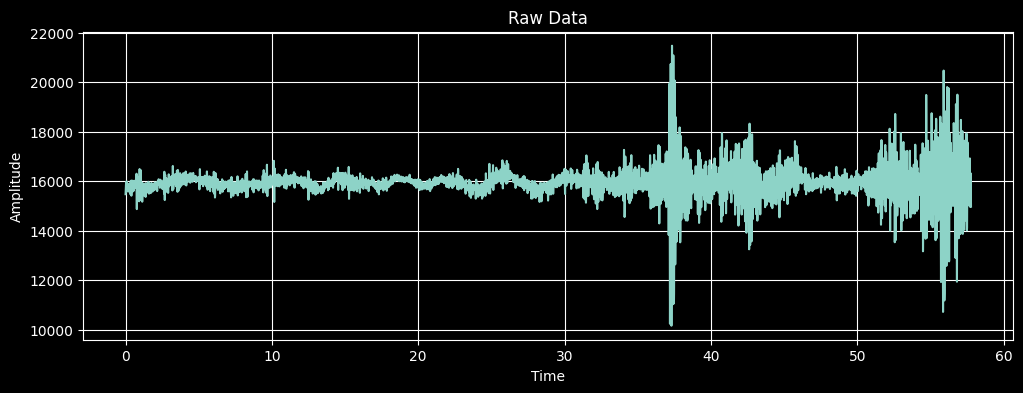

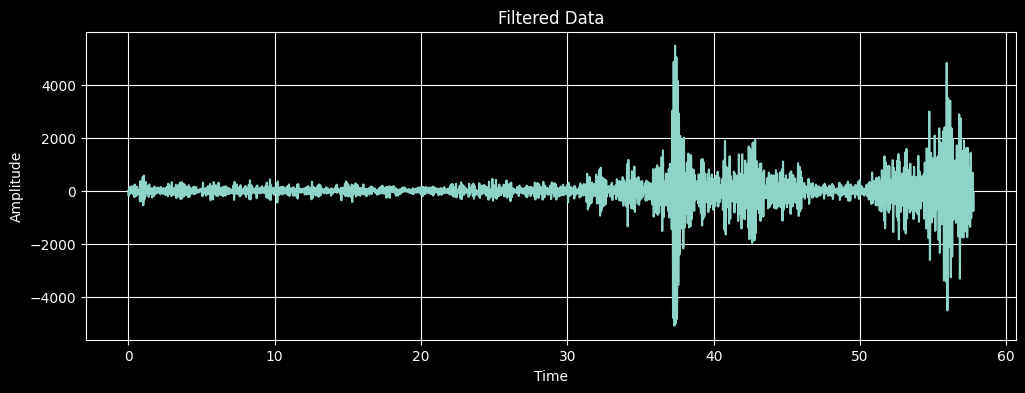

KeyboardInterrupt: 

In [4]:
while True:
    endTime = UTCDateTime.now()
    startTime = endTime - WINDOW

    try:
        st = client.get_waveforms(
            network=NETWORK,
            station=STATION,
            location=LOCATION,
            channel=CHANNEL,
            starttime=startTime,
            endtime=endTime)

        raw_tr = st[0].copy()
        filterd_tr = st[0].copy()

        #detrend e filtro
        filterd_tr.detrend('demean') #tolgo l'offset'
        filterd_tr.detrend('linear') #togliere i cambiamenti lenti
        filterd_tr.filter('bandpass',freqmin=1.0,freqmax=15.0) #banda segnali sismici utili

        clear_output(wait=True)

        print("Stazione:", filterd_tr.id)
        print("Start:", filterd_tr.stats.starttime)
        print("End:", filterd_tr.stats.endtime)
        print("Campioni:", filterd_tr.stats.npts)

        times_raw = raw_tr.times()
        times_filt = filterd_tr.times()

        plt.figure(figsize=(12,4))
        plt.plot(times_raw, raw_tr.data)
        plt.title("Raw Data")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(12,4))
        plt.plot(times_filt, filterd_tr.data)
        plt.title("Filtered Data")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.show()

    except FDSNNoDataException:
        print("Nessun dato disponibile, attendo...")
        time.sleep(INTERVAL)
        continue

    except Exception as e:
        print("Errore:", e)
        time.sleep(INTERVAL)
        continue

    time.sleep(INTERVAL)



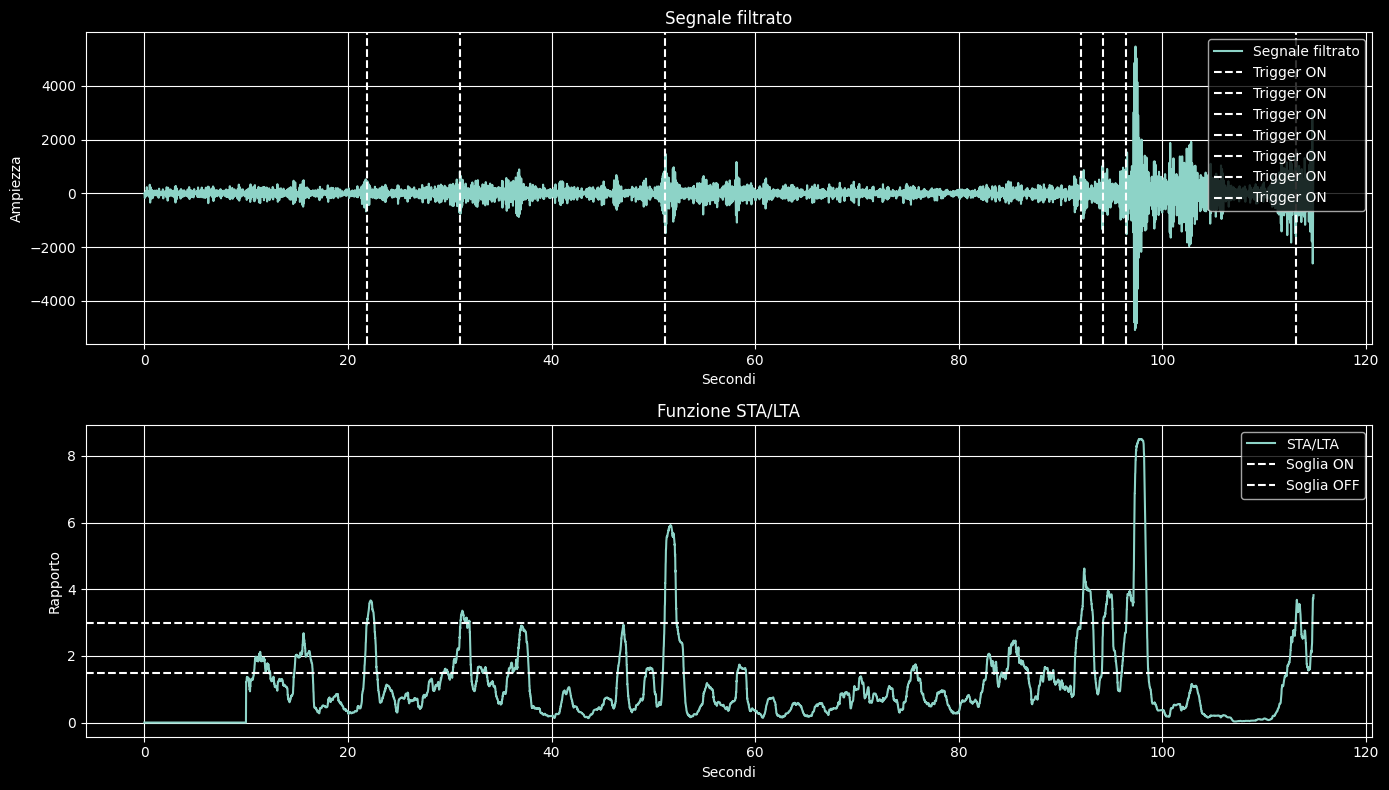

Trigger trovati: [[ 2190  2285]
 [ 3105  3209]
 [ 5111  5299]
 [ 9199  9336]
 [ 9419  9554]
 [ 9648  9862]
 [11310 11486]]


In [5]:
endTime2 = UTCDateTime.now() -20
startTime2 = endTime - 120

st = client.get_waveforms(
        network=NETWORK,
        station=STATION,
        location=LOCATION,
        channel=CHANNEL,
        starttime=startTime2,
        endtime=endTime2)

tr = st[0].copy()

#pulizia segnale
tr.detrend('demean')
tr.detrend('linear')
tr.filter('bandpass',freqmin=1.0,freqmax=15.0)

#freq di campionamento
df = tr.stats.sampling_rate

#finestra STA/LTA
nsta = int(1.0 * df)
nlta = int(10.0 * df)

cft = classic_sta_lta(tr.data,nsta,nlta)

# soglie trigger
thr_on = 3.0
thr_off = 1.5

on_off = trigger_onset(cft,thr_on,thr_off)

times = tr.times()

plt.figure(figsize=(14, 8))

# grafico segnale
plt.subplot(2, 1, 1)
plt.plot(times, tr.data, label="Segnale filtrato")
for pick in on_off:
    plt.axvline(times[pick[0]], linestyle="--", label="Trigger ON")
plt.title("Segnale filtrato")
plt.xlabel("Secondi")
plt.ylabel("Ampiezza")
plt.grid()
plt.legend()

# grafico STA/LTA
plt.subplot(2, 1, 2)
plt.plot(times, cft, label="STA/LTA")
plt.axhline(thr_on, linestyle="--", label="Soglia ON")
plt.axhline(thr_off, linestyle="--", label="Soglia OFF")
plt.title("Funzione STA/LTA")
plt.xlabel("Secondi")
plt.ylabel("Rapporto")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

print("Trigger trovati:", on_off)